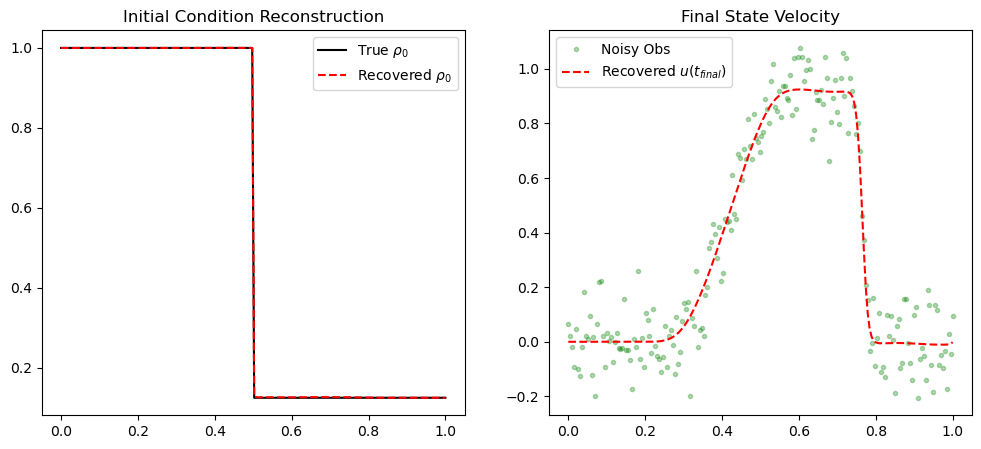

In [8]:
import torch
import matplotlib.pyplot as plt

gamma = 1.4
Nx = 200
x = torch.linspace(0, 1, Nx)
dx = x[1] - x[0]
CFL = 0.5
t_final = 0.15 # Slightly reduced for faster iteration

# ===============================
# Differentiable flux
# ===============================
def flux(U):
    rho, mom, E = U
    u = mom / (rho + 1e-8)
    p = (gamma - 1) * (E - 0.5 * rho * u**2)
    return torch.stack([mom, mom * u + p, (E + p) * u])

# ===============================
# Differentiable forward solver
# ===============================
def forward_solve(U0):
    U = U0.clone()
    t = 0.0
    while t < t_final:
        rho = U[0]
        u = U[1] / (rho + 1e-8)
        p = (gamma - 1) * (U[2] - 0.5 * rho * u**2)
        c = torch.sqrt(torch.clamp(gamma * p / (rho + 1e-8), min=1e-6))

        dt = CFL * dx / torch.max(torch.abs(u) + c)
        if t + dt > t_final: dt = t_final - t

        F = flux(U)
        Unew = U.clone()

        # Simple Rusanov (Lax-Friedrichs) Flux
        smax = torch.max(torch.abs(u) + c)
        FL = 0.5 * (F[:, :-1] + F[:, 1:]) - 0.5 * smax * (U[:, 1:] - U[:, :-1])
        
        # Update interior cells
        Unew[:, 1:-1] = U[:, 1:-1] - dt/dx * (FL[:, 1:] - FL[:, :-1])
        
        U = Unew
        t += dt
    return U

# ===============================
# True solution (generate data)
# ===============================
with torch.no_grad():
    rho0_true = torch.where(x < 0.5, 1.0, 0.125)
    u0_true = torch.zeros_like(x)
    p0_true = torch.where(x < 0.5, 1.0, 0.1)
    E0_true = p0_true / (gamma - 1) + 0.5 * rho0_true * u0_true**2
    U0_true = torch.stack([rho0_true, rho0_true * u0_true, E0_true])
    
    U_final_true = forward_solve(U0_true)
    u_obs = (U_final_true[1] / U_final_true[0]) + 0.10 * torch.randn(Nx)

# ===============================
# RECONSTRUCTION VIA ADJOINT
# ===============================

# Initial guess: smoothed/perturbed version of the true IC
U0 = U0_true.clone().detach().requires_grad_(True) 
# Note: In a real blind case, you'd start with a flat or linear guess.

optimizer = torch.optim.LBFGS([U0], lr=1, max_iter=20)

# Weights for the loss terms
w_tvd = 1e-4  # TVD weight
w_bc = 1.0    # BC weight

def closure():
    optimizer.zero_grad()
    
    # 1. Forward Pass
    U_end = forward_solve(U0)
    u_end = U_end[1] / (U_end[0] + 1e-8)
    
    # 2. Data Loss (MSE)
    loss_data = torch.mean((u_end - u_obs)**2)
    
    # 3. TVD Loss (Total Variation Regularization on the initial state U0)
    # Penalizes high-frequency oscillations in Density, Momentum, and Energy
    loss_tvd = torch.sum(torch.abs(U0[:, 1:] - U0[:, :-1]))
    
    # 4. BC Loss (Penalty for deviating from expected Dirichlet boundaries at t=0)
    # We assume the far-left and far-right states are fixed/known.
    loss_bc = torch.sum((U0[:, 0] - U0_true[:, 0])**2) + \
              torch.sum((U0[:, -1] - U0_true[:, -1])**2)
    
    total_loss = 0.1*loss_data + w_tvd * loss_tvd + w_bc * loss_bc
    
    total_loss.backward()
    return total_loss

optimizer.step(closure)

# ===============================
# Plot Results
# ===============================
U_rec_final = forward_solve(U0.detach())
u_rec_final = U_rec_final[1] / U_rec_final[0]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Initial Condition Reconstruction")
plt.plot(x, U0_true[0].numpy(), 'k', label="True $\\rho_0$")
plt.plot(x, U0[0].detach().numpy(), 'r--', label="Recovered $\\rho_0$")
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Final State Velocity")
plt.plot(x, u_obs.numpy(), 'g.', alpha=0.3, label="Noisy Obs")
plt.plot(x, u_rec_final.numpy(), 'r--', label="Recovered $u(t_{final})$")
plt.legend()
plt.show()